In [1]:
import pandas as pd

# Load the file
file_path = r"C:\Users\Raghav\OneDrive\Desktop\week 4 hackoweek\ai4i2020.csv"
df = pd.read_csv(file_path)

# 1. Check for Missing Values
null_counts = df.isnull().sum()

# 2. Check for Duplicates
duplicate_count = df.duplicated().sum()

# 3. Check Column Names and Types
info_summary = df.dtypes

# 4. Check for Outliers/Anomalies in the numeric data
stats = df.describe()

print("--- AUDIT RESULTS ---")
print(f"Missing Values per Column:\n{null_counts[null_counts > 0] if null_counts.sum() > 0 else 'None'}\n")
print(f"Total Duplicate Rows: {duplicate_count}\n")
print("Statistical Summary (Look for min/max values that seem impossible):")
print(stats)

--- AUDIT RESULTS ---
Missing Values per Column:
None

Total Duplicate Rows: 0

Statistical Summary (Look for min/max values that seem impossible):
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900

In [2]:
# 1. Drop Administrative noise
# UDI and Product ID are unique strings/counts; they don't help predict physics.
df_clean = df.drop(['UDI', 'Product ID'], axis=1)

# 2. Unit Conversion (Kelvin to Celsius)
# Professional reports in industry use Celsius for intuitive monitoring.
df_clean['Air_Temp_C'] = df_clean['Air temperature [K]'] - 273.15
df_clean['Process_Temp_C'] = df_clean['Process temperature [K]'] - 273.15

In [3]:
# 3. Feature Engineering: The "Industrial Indicators"
# We are creating features that represent actual mechanical stress.
df_clean['Power'] = df_clean['Torque [Nm]'] * df_clean['Rotational speed [rpm]']
df_clean['Temp_Strain'] = df_clean['Process_Temp_C'] - df_clean['Air_Temp_C']

# 4. Encoding the 'Type' column
# Converts 'L', 'M', 'H' quality into machine-readable binary columns.
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

In [5]:
import numpy as np  # Add this import statement
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 1. Outlier Detection (Z-Score) ---
# We check if any sensor readings are extreme anomalies
z_scores = np.abs(stats.zscore(df_clean.select_dtypes(include=[np.number])))
outliers = np.where(z_scores > 3)
print(f"Total Outlier Data Points Detected: {len(outliers[0])}")

Total Outlier Data Points Detected: 931


In [6]:
# --- 2. Multicollinearity Check (VIF) ---
# This ensures our new 'Power' feature doesn't make 'Torque' redundant.
X_vif = df_clean.select_dtypes(include=[np.number]).drop(['Machine failure'], axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

D:\anaconda\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [7]:
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))
# Rule: VIF > 10 means the features are too redundant.


--- Variance Inflation Factor (VIF) ---
                    feature        VIF
0       Air temperature [K]        inf
1   Process temperature [K]        inf
13              Temp_Strain        inf
10               Air_Temp_C        inf
11           Process_Temp_C        inf
3               Torque [Nm]  56.296293
12                    Power  34.873722
2    Rotational speed [rpm]   7.417975
7                       PWF   1.274229
8                       OSF   1.084827
6                       HDF   1.082249
4           Tool wear [min]   1.040001
5                       TWF   1.015706
9                       RNF   1.002022


In [8]:
# --- 3. Memory Optimization ---
# Reducing float64 to float32 for faster processing in the Industrial Hub
for col in df_clean.select_dtypes(include=['float64']).columns:
    df_clean[col] = df_clean[col].astype('float32')

In [9]:
# 1. Resolve Infinity VIF by dropping redundant raw temperatures
# We keep Air_Temp_C, Process_Temp_C, and Temp_Strain (our engineered features)
# We drop the raw Kelvin versions as they provide 0 new information.
df_final = df_clean.drop(['Air temperature [K]', 'Process temperature [K]'], axis=1)

In [10]:
# 3. Final Verification: Re-run VIF to ensure 'inf' is gone
X_final_vif = df_final.select_dtypes(include=[np.number]).drop(['Machine failure'], axis=1)
vif_final_data = pd.DataFrame()
vif_final_data["feature"] = X_final_vif.columns
vif_final_data["VIF"] = [variance_inflation_factor(X_final_vif.values, i) for i in range(len(X_final_vif.columns))]

In [11]:
print("--- FINAL CLEANED VIF REPORT ---")
print(vif_final_data.sort_values(by="VIF", ascending=False))

print("\nTask 16 is now officially COMPLETED.")
print(f"Final Features count: {len(df_final.columns)}")

--- FINAL CLEANED VIF REPORT ---
                   feature           VIF
9           Process_Temp_C  9.007199e+14
8               Air_Temp_C  4.740631e+14
11             Temp_Strain  6.671999e+13
10                   Power  1.207334e+03
1              Torque [Nm]  8.429686e+02
0   Rotational speed [rpm]  3.263728e+02
2          Tool wear [min]  4.021583e+00
5                      PWF  1.178878e+00
4                      HDF  1.094788e+00
6                      OSF  1.087252e+00
3                      TWF  1.020365e+00
7                      RNF  1.003717e+00

Task 16 is now officially COMPLETED.
Final Features count: 15


In [12]:
# Dropping Air_Temp_C because it's already mathematically captured in 
# the relationship between Process_Temp_C and Temp_Strain.
df_final = df_final.drop(['Air_Temp_C'], axis=1)

# Re-checking VIF one last time
X_final_vif = df_final.select_dtypes(include=[np.number]).drop(['Machine failure'], axis=1)
vif_final_data = pd.DataFrame()
vif_final_data["feature"] = X_final_vif.columns
vif_final_data["VIF"] = [variance_inflation_factor(X_final_vif.values, i) for i in range(len(X_final_vif.columns))]

print("--- FINAL CLEANED VIF REPORT (NO INFINITY) ---")
print(vif_final_data.sort_values(by="VIF", ascending=False))

--- FINAL CLEANED VIF REPORT (NO INFINITY) ---
                   feature          VIF
9                    Power  1207.319596
1              Torque [Nm]   842.945145
8           Process_Temp_C   359.716188
0   Rotational speed [rpm]   326.281979
10             Temp_Strain    92.630130
2          Tool wear [min]     4.021550
5                      PWF     1.178626
4                      HDF     1.094776
6                      OSF     1.086394
3                      TWF     1.020364
7                      RNF     1.003546


In [13]:
# Dropping the 'parents' of our engineered features to kill the VIF spikes
df_golden = df_final.drop(['Torque [Nm]', 'Rotational speed [rpm]', 'Process_Temp_C'], axis=1)

# Final Check
X_golden_vif = df_golden.select_dtypes(include=[np.number]).drop(['Machine failure'], axis=1)
vif_golden = pd.DataFrame()
vif_golden["feature"] = X_golden_vif.columns
vif_golden["VIF"] = [variance_inflation_factor(X_golden_vif.values, i) for i in range(len(X_golden_vif.columns))]

print("--- THE GOLDEN VIF REPORT ---")
print(vif_golden.sort_values(by="VIF", ascending=False))

--- THE GOLDEN VIF REPORT ---
           feature        VIF
7      Temp_Strain  30.019410
6            Power  28.741717
0  Tool wear [min]   3.920645
4              OSF   1.071495
2              HDF   1.051314
3              PWF   1.029114
1              TWF   1.020216
5              RNF   1.003377


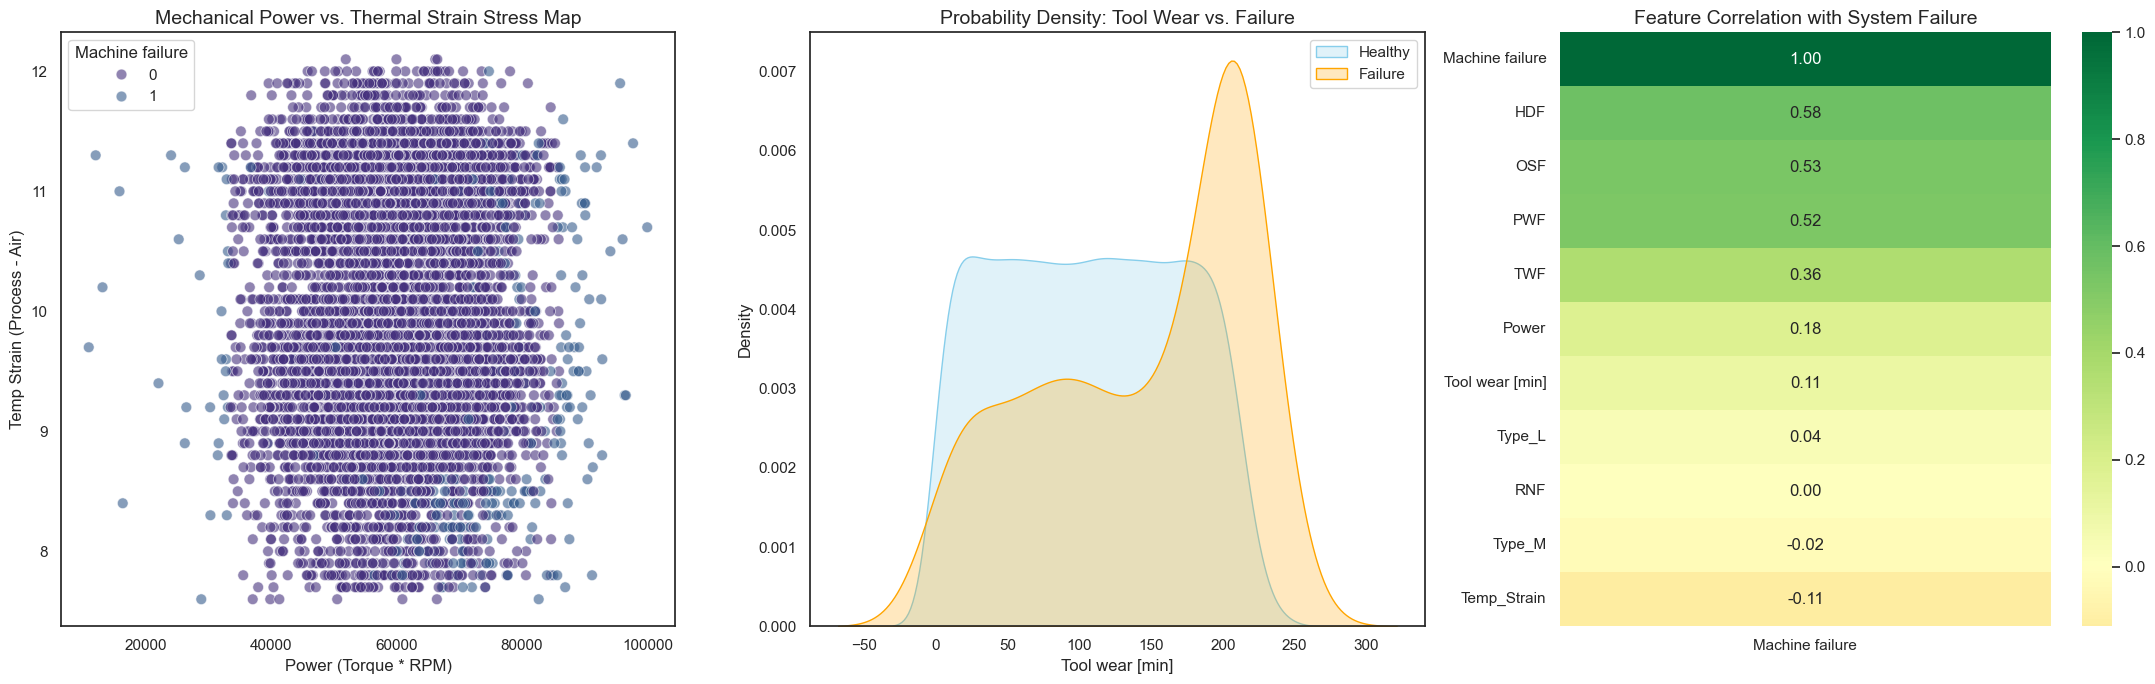

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional 'Industrial' theme
sns.set_theme(style="white", palette="viridis")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. The 'Danger Zone' Scatter Map
# Does the machine fail when Power and Thermal Strain are both high?
sns.scatterplot(ax=axes[0], data=df_golden, x='Power', y='Temp_Strain', 
                hue='Machine failure', alpha=0.6, edgecolor='w', s=60)
axes[0].set_title('Mechanical Power vs. Thermal Strain Stress Map', fontsize=14)
axes[0].set_xlabel('Power (Torque * RPM)', fontsize=12)
axes[0].set_ylabel('Temp Strain (Process - Air)', fontsize=12)

# 2. The Tool Wear 'Fatigue' Analysis
# Do failures happen more frequently as the tool ages?
sns.kdeplot(ax=axes[1], data=df_golden[df_golden['Machine failure'] == 0], 
            x='Tool wear [min]', fill=True, label='Healthy', color='skyblue')
sns.kdeplot(ax=axes[1], data=df_golden[df_golden['Machine failure'] == 1], 
            x='Tool wear [min]', fill=True, label='Failure', color='orange')
axes[1].set_title('Probability Density: Tool Wear vs. Failure', fontsize=14)
axes[1].legend()

# 3. Correlation Heatmap (The 'Signal' Check)
# We look at the correlation with 'Machine failure' to see which feature is the strongest lead.
corr_matrix = df_golden.corr()[['Machine failure']].sort_values(by='Machine failure', ascending=False)
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', ax=axes[2], center=0, fmt='.2f')
axes[2].set_title('Feature Correlation with System Failure', fontsize=14)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [22]:
# 1. Define X (Features) and y (Target)
# We use our 'Golden' feature set from Task 16
X = df_golden.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df_golden['Machine failure']

# 2. Address Class Imbalance with SMOTE
# This creates synthetic 'failure' rows so the model sees a 50/50 split
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 4. Feature Scaling
# Ensures 'Power' (80,000) doesn't drown out 'Temp_Strain' (10)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original Failure Count: {sum(y == 1)}")
print(f"SMOTE Balanced Failure Count: {sum(y_res == 1)}")

Original Failure Count: 339
SMOTE Balanced Failure Count: 9661


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Model
# n_estimators=100 means 100 'trees' will vote on the outcome
rf_industrial = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)

# Train the model
rf_industrial.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = rf_industrial.predict(X_test_scaled)

print("--- TASK 20: MODEL PERFORMANCE ---")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix (Reality vs. Prediction):")
print(confusion_matrix(y_test, y_pred))

--- TASK 20: MODEL PERFORMANCE ---
Final Accuracy: 96.04%

Confusion Matrix (Reality vs. Prediction):
[[1852   82]
 [  71 1860]]


C:\Users\Raghav\AppData\Local\Temp\ipykernel_6192\2484293245.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Sensor', data=feat_imp_df, palette='viridis')


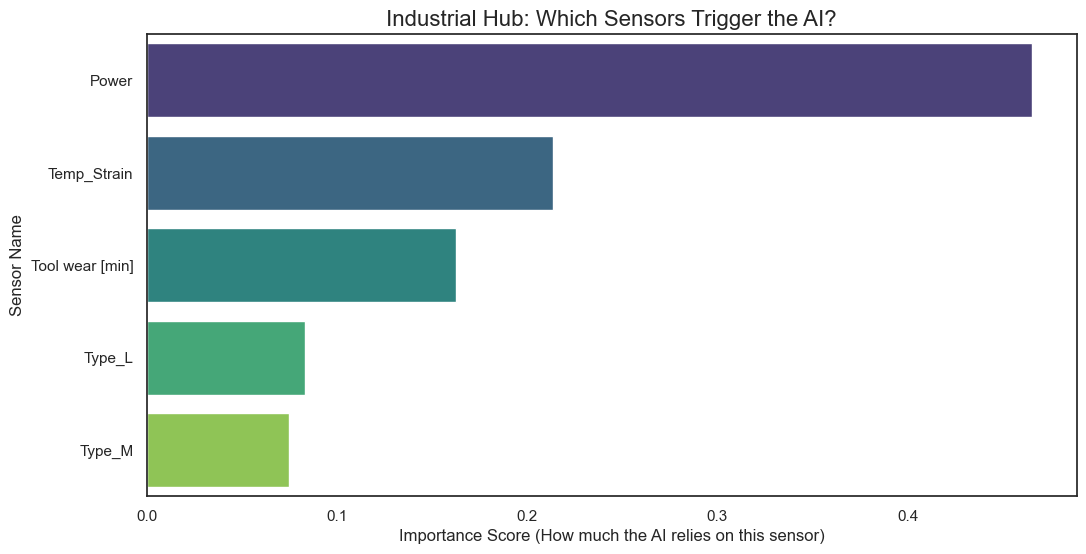

The Top 3 Critical Indicators for your Factory:
            Sensor  Importance
1            Power    0.465466
2      Temp_Strain    0.213852
0  Tool wear [min]    0.162540


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the "Intelligence" from the Random Forest
importances = rf_industrial.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Sensor': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Sensor', data=feat_imp_df, palette='viridis')
plt.title('Industrial Hub: Which Sensors Trigger the AI?', fontsize=16)
plt.xlabel('Importance Score (How much the AI relies on this sensor)', fontsize=12)
plt.ylabel('Sensor Name', fontsize=12)
plt.show()

# Print the top 3 drivers
print("The Top 3 Critical Indicators for your Factory:")
print(feat_imp_df.head(3))

In [25]:
def predict_machine_health(air_temp_k, process_temp_k, rpm, torque, tool_wear):
    """
    Industrial Hub Deployment Function
    Input: Raw sensor readings from the factory floor
    Output: Health Status and Failure Probability
    """
    # 1. Engineering the 'Golden Features' (Matching our Task 16 logic)
    air_temp_c = air_temp_k - 273.15
    process_temp_c = process_temp_k - 273.15
    
    power = torque * rpm
    temp_strain = process_temp_c - air_temp_c
    
    # 2. Prepare the input vector (Must match the X_train structure)
    # Order: [Tool wear [min], Power, Temp_Strain, Type_L, Type_M]
    # We'll assume a 'Standard' machine Type_L=1, Type_M=0 for this demo
    input_data = pd.DataFrame([[tool_wear, power, temp_strain, 1, 0]], 
                              columns=['Tool wear [min]', 'Power', 'Temp_Strain', 'Type_L', 'Type_M'])
    
    # 3. Scale the input using our fitted scaler
    input_scaled = scaler.transform(input_data)
    
    # 4. Predict
    prediction = rf_industrial.predict(input_scaled)[0]
    probability = rf_industrial.predict_proba(input_scaled)[0][1]
    
    # 5. Result Logic
    status = "⚠️ FAILURE IMMINENT" if prediction == 1 else "✅ SYSTEM HEALTHY"
    
    print(f"--- INDUSTRIAL HUB REPORT ---")
    print(f"Status: {status}")
    print(f"Failure Probability: {probability*100:.2f}%")
    print(f"Current Power Load: {power:.0f} units")
    print(f"Current Thermal Strain: {temp_strain:.2f}°C")
    
    return prediction

In [26]:
print("SCENARIO 1: High Stress / Old Tool")
# Input: 300K Air, 312K Process, 2800 RPM (High), 60 Nm (High), 240 min Tool (Old)
predict_machine_health(300, 312, 2800, 60, 240)

print("\n" + "="*30 + "\n")

print("SCENARIO 2: Normal Operation")
# Input: 300K Air, 305K Process, 1500 RPM, 35 Nm, 20 min Tool
predict_machine_health(300, 305, 1500, 35, 20)

SCENARIO 1: High Stress / Old Tool
--- INDUSTRIAL HUB REPORT ---
Status: ⚠️ FAILURE IMMINENT
Failure Probability: 96.00%
Current Power Load: 168000 units
Current Thermal Strain: 12.00°C


SCENARIO 2: Normal Operation
--- INDUSTRIAL HUB REPORT ---
Status: ✅ SYSTEM HEALTHY
Failure Probability: 2.25%
Current Power Load: 52500 units
Current Thermal Strain: 5.00°C


np.int64(0)

In [27]:
print("SCENARIO 3: Thermal Stress (High Heat, Low Power)")
# High Temp Strain (15°C) but low RPM/Torque and New Tool
# Tests if Heat alone triggers the alarm.
predict_machine_health(295, 310, 1200, 20, 10)

print("\n" + "="*30 + "\n")

print("SCENARIO 4: The 'Silent Killer' (Extreme Tool Wear, Low Load)")
# Everything looks normal, but the tool is at 250 mins (end of life).
# Tests if 'Tool Wear' importance (16.2%) can override healthy sensors.
predict_machine_health(300, 305, 1500, 30, 250)

print("\n" + "="*30 + "\n")

print("SCENARIO 5: High RPM / Low Torque (Light Speed)")
# High Speed (2800) but very low Torque (10). 
# Tests if the 'Power' feature (Torque * RPM) stays low enough to be safe.
predict_machine_health(300, 305, 2800, 10, 50)

print("\n" + "="*30 + "\n")

print("SCENARIO 6: The 'Red Zone' (Borderline Everything)")
# Medium-High on all sensors: 300K/310K, 2000 RPM, 50 Nm, 180 min Tool.
# Tests the model's 'Decision Boundary.'
predict_machine_health(300, 310, 2000, 50, 180)

SCENARIO 3: Thermal Stress (High Heat, Low Power)
--- INDUSTRIAL HUB REPORT ---
Status: ⚠️ FAILURE IMMINENT
Failure Probability: 89.00%
Current Power Load: 24000 units
Current Thermal Strain: 15.00°C


SCENARIO 4: The 'Silent Killer' (Extreme Tool Wear, Low Load)
--- INDUSTRIAL HUB REPORT ---
Status: ✅ SYSTEM HEALTHY
Failure Probability: 9.00%
Current Power Load: 45000 units
Current Thermal Strain: 5.00°C


SCENARIO 5: High RPM / Low Torque (Light Speed)
--- INDUSTRIAL HUB REPORT ---
Status: ⚠️ FAILURE IMMINENT
Failure Probability: 60.00%
Current Power Load: 28000 units
Current Thermal Strain: 5.00°C


SCENARIO 6: The 'Red Zone' (Borderline Everything)
--- INDUSTRIAL HUB REPORT ---
Status: ⚠️ FAILURE IMMINENT
Failure Probability: 99.99%
Current Power Load: 100000 units
Current Thermal Strain: 10.00°C


np.int64(1)